In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
# os.environ["JAX_PLATFORM_NAME"] = "cpu"  # force CPU backend in this notebook


In [2]:
import netket as nk
import netket.experimental as nkx
import numpy as np
import jax
import jax.numpy as jnp
from netket.operator.fermion import create as cdag
from netket.operator.fermion import destroy as c
from netket.operator.fermion import number as nc
print(jax.devices())

∣NK⟩ Tip: You can load logged data with nk.utils.history.HistoryDict.from_file(data.log).

[CudaDevice(id=0)]


In [3]:
#single particle parameters

t1 = 1.0
t2 = -1/(4 * np.cos(0.65))
phi = 0.65
m = 0.

#parameters from DMRG paper by Zalatel et al on Haldane model: t1 = 1.0, t2 = -1/(4 * np.cos(0.65)), phi = 0.65

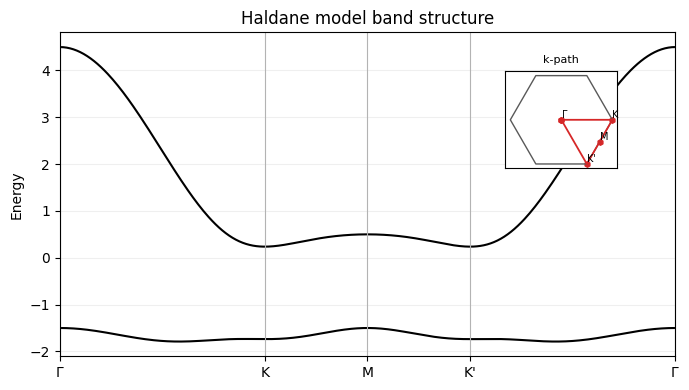

K point used = [4.18879020, 0.00000000]
Berry curvature at K (lower band): 0.38452690
Trace of quantum metric at K (lower band): 0.38452690
Estimated Chern number (lower band) = 1.0000000000
Estimated quantum weight (lower band) = 1.0664954341


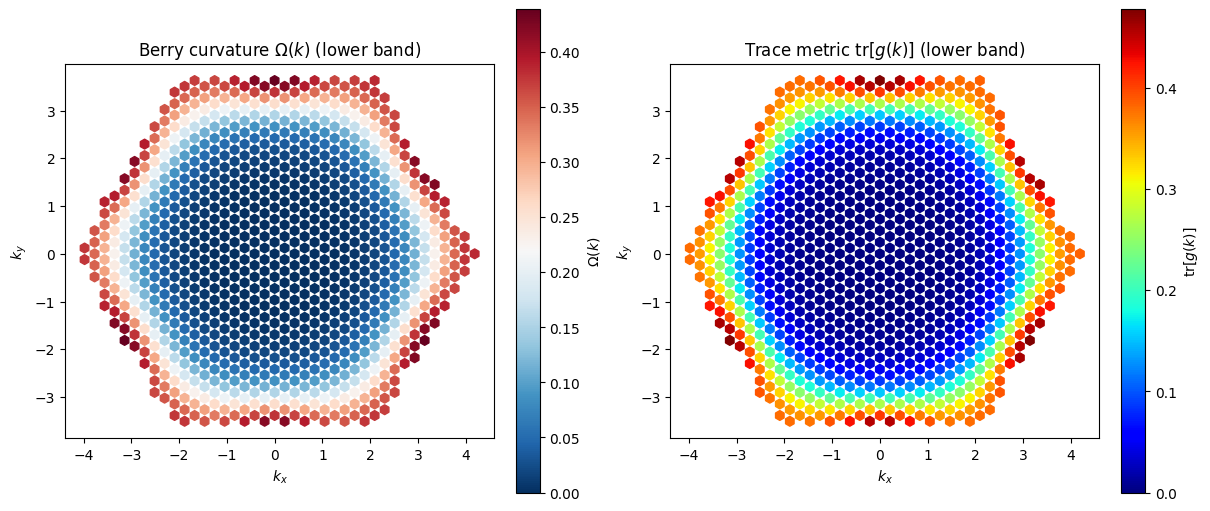

In [4]:
#single particle properties

import matplotlib.pyplot as plt

from aidan_custom.geometry import (
    ANNN_VECTORS,
    DELTA_VECTORS,
    PRIMITIVE_A1,
    PRIMITIVE_A2,
    SUBLATTICE_A_OFFSET,
    SUBLATTICE_B_OFFSET,
    first_bz_hexagon_vertices,
    fold_to_shortest_k,
    high_symmetry_points,
    k_path_gamma_k_m_kp_gamma,
    reciprocal_vectors,
    sample_shortest_representative_bz,
)
from aidan_custom.bandstructure import (
    berry_curvature_and_metric_trace_at_k,
    eigenvalues_at_k,
)

# Keep the same names used throughout the notebook.
a1 = PRIMITIVE_A1.copy()
a2 = PRIMITIVE_A2.copy()
rA = SUBLATTICE_A_OFFSET.copy()
rB = SUBLATTICE_B_OFFSET.copy()
delta_vectors = DELTA_VECTORS
annn_vectors = ANNN_VECTORS

b1, b2 = reciprocal_vectors(a1, a2)

# Band structure along high-symmetry path (same orientation used everywhere)
k_points, x, x_nodes, labels = k_path_gamma_k_m_kp_gamma(120, b1, b2)
bands = np.array(
    [eigenvalues_at_k(kx, ky, t1=t1, t2=t2, phi=phi, m=m) for kx, ky in k_points]
)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, bands[:, 0], color="black")
ax.plot(x, bands[:, 1], color="black")
for xn in x_nodes:
    ax.axvline(xn, color="0.7", lw=0.8)
ax.set_xticks(x_nodes)
ax.set_xticklabels(labels)
ax.set_xlim(x[0], x[-1])
ax.set_ylabel("Energy")
ax.set_title("Haldane model band structure")
ax.grid(axis="y", alpha=0.2)

# Inset: k-space path Γ→K→M→K'→Γ with first-BZ boundary
gamma, k_node, m_node, kp_node = high_symmetry_points(b1, b2)
path_nodes = np.array([gamma, k_node, m_node, kp_node, gamma])
bz_hex = first_bz_hexagon_vertices(b1, b2)
bz_hex_closed = np.vstack([bz_hex, bz_hex[0]])

ax_in = ax.inset_axes([0.69, 0.58, 0.25, 0.30])
ax_in.plot(bz_hex_closed[:, 0], bz_hex_closed[:, 1], color="0.35", lw=1.0)
ax_in.plot(path_nodes[:, 0], path_nodes[:, 1], color="tab:red", lw=1.3)
ax_in.scatter(path_nodes[:, 0], path_nodes[:, 1], s=16, c="tab:red", marker="h")
for point, label in zip(path_nodes[:-1], labels[:-1]):
    ax_in.text(point[0], point[1], label, fontsize=7, ha="left", va="bottom")
ax_in.set_xticks([])
ax_in.set_yticks([])
ax_in.set_aspect("equal", "box")
ax_in.set_title("k-path", fontsize=8)
plt.tight_layout()
plt.show()

# Example QGT-derived values at K
_, kK, _, _ = high_symmetry_points(b1, b2)
omega_K, tr_g_K = berry_curvature_and_metric_trace_at_k(
    kK[0], kK[1], t1=t1, t2=t2, phi=phi, m=m, band="lower"
)
print(f"K point used = [{kK[0]:.8f}, {kK[1]:.8f}]")
print(f"Berry curvature at K (lower band): {omega_K:.8f}")
print(f"Trace of quantum metric at K (lower band): {tr_g_K:.8f}")

# Scatter plots over first BZ by shortest-representative map
# (independent local override for this cell)
Lx_bz_plot = 30
Ly_bz_plot = Lx_bz_plot

# Use all mesh points (N_k = Lx_bz_plot*Ly_bz_plot) for BZ integrals.
k_bz_all = sample_shortest_representative_bz(
    Lx_bz_plot, Ly_bz_plot, b1, b2, unique=False
)
if k_bz_all.size == 0:
    raise ValueError("No BZ points sampled. Increase Lx_bz_plot/Ly_bz_plot.")

berry_all = np.empty(k_bz_all.shape[0], dtype=float)
trg_all = np.empty(k_bz_all.shape[0], dtype=float)
for i, (kx, ky) in enumerate(k_bz_all):
    omega, trg = berry_curvature_and_metric_trace_at_k(
        kx,
        ky,
        t1=t1,
        t2=t2,
        phi=phi,
        m=m,
        band="lower",
    )
    berry_all[i] = omega
    trg_all[i] = trg

# First-BZ area and quadrature weights for uniform mesh of this system size.
area_bz = abs(b1[0] * b2[1] - b1[1] * b2[0])
n_k = Lx_bz_plot * Ly_bz_plot
dk_area = area_bz / n_k
chern_number = (dk_area / (2.0 * np.pi)) * np.sum(berry_all)
quantum_weight = dk_area * np.sum(trg_all) / (2 * np.pi)
print(f"Estimated Chern number (lower band) = {chern_number:.10f}")
print(f"Estimated quantum weight (lower band) = {quantum_weight:.10f}")

# Unique representatives for cleaner scatter visualization.
k_bz = sample_shortest_representative_bz(Lx_bz_plot, Ly_bz_plot, b1, b2, unique=True)
berry_bz = np.empty(k_bz.shape[0], dtype=float)
trg_bz = np.empty(k_bz.shape[0], dtype=float)
for i, (kx, ky) in enumerate(k_bz):
    omega, trg = berry_curvature_and_metric_trace_at_k(
        kx,
        ky,
        t1=t1,
        t2=t2,
        phi=phi,
        m=m,
        band="lower",
    )
    berry_bz[i] = omega
    trg_bz[i] = trg

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
marker_size = 50
sc0 = axes[0].scatter(
    k_bz[:, 0],
    k_bz[:, 1],
    s=marker_size,
    c=berry_bz,
    cmap="RdBu_r",
    marker="h",
)
axes[0].set_title(r"Berry curvature $\Omega(k)$ (lower band)")
axes[0].set_xlabel(r"$k_x$")
axes[0].set_ylabel(r"$k_y$")
axes[0].set_aspect("equal", "box")
fig.colorbar(sc0, ax=axes[0], label=r"$\Omega(k)$")

sc1 = axes[1].scatter(
    k_bz[:, 0],
    k_bz[:, 1],
    s=marker_size,
    c=trg_bz,
    cmap="jet",
    marker="h",
)
axes[1].set_title(r"Trace metric $\mathrm{tr}[g(k)]$ (lower band)")
axes[1].set_xlabel(r"$k_x$")
axes[1].set_ylabel(r"$k_y$")
axes[1].set_aspect("equal", "box")
fig.colorbar(sc1, ax=axes[1], label=r"$\mathrm{tr}[g(k)]$")
plt.show()


In [5]:
# many-body system parameters
# Haldane model parameters
Lx, Ly = 4, 3
V1 = 10.
n_fermions = 4

from aidan_custom.haldane_model import build_haldane_hamiltonian
from aidan_custom.models import LogSlaterDeterminant, LogSlaterJastrow

graph, hi, ham = build_haldane_hamiltonian(
    Lx=Lx,
    Ly=Ly,
    t1=t1,
    t2=t2,
    phi=phi,
    m=m,
    V1=V1,
    n_fermions=n_fermions,
)

assert n_fermions <= graph.n_nodes
print(f"n_sites={graph.n_nodes}, n_fermions={hi.n_fermions}")
print(f"hilbert={hi}")
print(f"V1={V1}")
print(f"max_conn_size={ham.max_conn_size}")


n_sites=24, n_fermions=4
hilbert=SpinOrbitalFermions(n_orbitals=24, n_fermions=4)
V1=10.0
max_conn_size=37


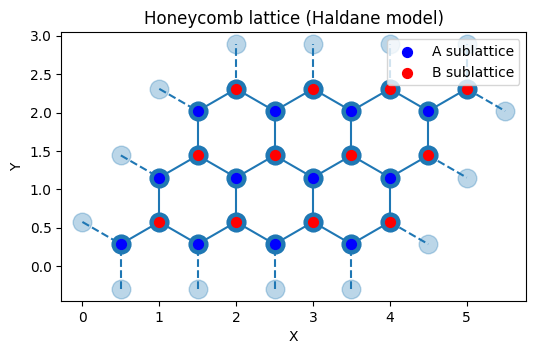

In [6]:
import matplotlib.pyplot as plt
# Visualize the lattice using NetKet built-in drawing
ax = graph.draw(
    distance_order=1,
    draw_text=False,
    draw_basis_vectors=False,
    draw_unit_cell=False,
    node_size=180,
    figsize=(6, 6),
    show=False
)
# Highlight the two honeycomb sublattices (A/B)
coords = graph.basis_coords
positions = graph.positions
a_sites = coords[:, 2] == 0
b_sites = coords[:, 2] == 1
ax.scatter(
    positions[a_sites, 0],
    positions[a_sites, 1],
    s=50,
    c="blue",
    label="A sublattice",
    zorder=5,
)
ax.scatter(
    positions[b_sites, 0],
    positions[b_sites, 1],
    s=50,
    c="red",
    label="B sublattice",
    zorder=5,
)
ax.legend(loc="upper right")
ax.set_title("Honeycomb lattice (Haldane model)")
plt.show()


In [7]:
from aidan_custom.models import (
    LogSlaterBoseFormer,
    LogSlaterDeterminant,
    LogSlaterJastrow,
    LogSlaterSpatialViT,
    make_supercell_reciprocal_vectors_from_graph,
    make_translation_equivariant_pair_data_from_graph,
)
from aidan_custom.optimization import (
    exact_reference_ground_state_energy,
    log_optimization_diagnostics,
)


Sampling dictionary:

n_chains: number of independent Markov chains evolved in parallel (global across devices). See metropolis.py (line 256) and base.py (line 153).

sweep_size: number of Metropolis proposal/accept steps done before recording one next sample in each chain (subsampling interval). See metropolis.py (line 263), and loop at metropolis.py (line 462).

n_samples: total number of kept samples returned by MCState.sample(...) across all chains. Internally, chain length is ceil(n_samples / n_chains), so NetKet may round up to a multiple of n_chains. See state.py (line 58) and state.py (line 67).

n_discard_per_chain: burn-in samples discarded at the beginning of each chain before kept samples are drawn. See state.py (line 442) and discard call at state.py (line 557).

In [2]:
512*10

5120

In [ ]:
import optax

model_type = "slater_boseformer"  # options: "slater", "slater_jastrow", "slater_spatial_vit", "slater_boseformer"

# Optimization controls
n_iter = 1_000
n_samples = 1024 * 5
n_discard_per_chain = 4
sweep_size = 2 * n_fermions  # number of MC move proposals between sample measurements
n_chains = 512
sample_type = "FullSum" #"FullSum" "MC"

# Spatial-ViT controls (used only for model_type == "slater_spatial_vit")
vit_num_layers = 2 #Number of stacked spatial transformer encoder blocks.
vit_d_model = 16 #Token feature dimension d throughout the ViT.
vit_n_heads = 2 #Number of attention heads; each head has size d_head = d/n_heads
vit_mlp_hidden_factor = 2 #Expansion factor r in each block's FFN, so hidden is size r * d
vit_output_hidden_dim = 16 #Hidden dimension d_h in the final real/imag output dense layers
vit_xi_epsilon = 1.0e-6 #small positive stabilizer added to the learned \xi in the spatial envelope \xi

# BoseFormer controls (used only for model_type == "slater_boseformer")
boseformer_num_layers = 2
boseformer_d_model = 32
boseformer_n_heads = 2
boseformer_mlp_hidden_factor = 2
slater_init_mode = "random"  # options: "random", "noninteracting"

from aidan_custom.haldane_model import noninteracting_slater_orbitals_haldane
from aidan_custom.models import (
    LogSlaterBoseFormer,
    LogSlaterDeterminant,
    LogSlaterJastrow,
    LogSlaterSpatialViT,
    make_supercell_reciprocal_vectors_from_graph,
    make_translation_equivariant_pair_data_from_graph,
)
from aidan_custom.optimization import (
    exact_reference_ground_state_energy,
    log_optimization_diagnostics,
)

sampler = nk.sampler.MetropolisFermionHop(
    hi,
    graph=graph,
    n_chains=n_chains,
    sweep_size=sweep_size,
)

if model_type == "slater":
    model = LogSlaterDeterminant(hi, param_dtype=complex)
elif model_type == "slater_jastrow":
    model = LogSlaterJastrow(hi, param_dtype=complex, jastrow_param_dtype=complex)
elif model_type == "slater_spatial_vit":
    pair_classes, pair_distances, pair_vectors = make_translation_equivariant_pair_data_from_graph(graph)
    # print(
    #     f"Spatial pair classes: {pair_distances.size}; "
    #     f"pair_classes shape={pair_classes.shape}; pair_vectors shape={pair_vectors.shape}"
    # )

    # Flax modules are hashed in NetKet internals, so static attributes must be hashable.
    pair_classes_hashable = tuple(tuple(int(v) for v in row) for row in pair_classes)
    pair_distances_hashable = tuple(float(v) for v in pair_distances)

    slater_initial_m_orbitals = None
    if slater_init_mode == "noninteracting":
        slater_initial_m_orbitals = noninteracting_slater_orbitals_haldane(
            graph=graph,
            Lx=Lx,
            Ly=Ly,
            n_fermions=n_fermions,
            t1=t1,
            t2=t2,
            phi=phi,
            m=m,
        )
        print("Initializing Slater determinant from non-interacting ground-state orbitals.")
    elif slater_init_mode != "random":
        raise ValueError(f"Unknown slater_init_mode={slater_init_mode!r}")

    model = LogSlaterSpatialViT(
        hilbert=hi,
        num_layers=vit_num_layers,
        d_model=vit_d_model,
        n_heads=vit_n_heads,
        pair_classes=pair_classes_hashable,
        pair_distances=pair_distances_hashable,
        # VMC_SR currently requires homogeneous parameter dtypes across the model tree.
        slater_param_dtype=jnp.float64,
        slater_initial_m_orbitals=slater_initial_m_orbitals,
        mlp_hidden_factor=vit_mlp_hidden_factor,
        output_hidden_dim=vit_output_hidden_dim,
        xi_epsilon=vit_xi_epsilon,
    )
elif model_type == "slater_boseformer":
    g_vectors = make_supercell_reciprocal_vectors_from_graph(graph)
    positions_hashable = tuple(
        tuple(float(v) for v in row)
        for row in np.asarray(graph.positions, dtype=np.float64)
    )
    g_vectors_hashable = tuple(
        tuple(float(v) for v in row)
        for row in np.asarray(g_vectors, dtype=np.float64)
    )

    slater_initial_m_orbitals = None
    if slater_init_mode == "noninteracting":
        slater_initial_m_orbitals = noninteracting_slater_orbitals_haldane(
            graph=graph,
            Lx=Lx,
            Ly=Ly,
            n_fermions=n_fermions,
            t1=t1,
            t2=t2,
            phi=phi,
            m=m,
        )
        print("Initializing Slater determinant from non-interacting ground-state orbitals.")
    elif slater_init_mode != "random":
        raise ValueError(f"Unknown slater_init_mode={slater_init_mode!r}")

    model = LogSlaterBoseFormer(
        hilbert=hi,
        positions=positions_hashable,
        g_vectors=g_vectors_hashable,
        num_layers=boseformer_num_layers,
        d_model=boseformer_d_model,
        n_heads=boseformer_n_heads,
        slater_param_dtype=jnp.float64,
        slater_initial_m_orbitals=slater_initial_m_orbitals,
        boseformer_param_dtype=jnp.float64,
        mlp_hidden_factor=boseformer_mlp_hidden_factor,
    )
else:
    raise ValueError(f"Unknown model_type={model_type!r}")

if sample_type == "MC":
    vstate = nk.vqs.MCState(
        sampler,
        model,
        n_samples=n_samples,
        n_discard_per_chain=n_discard_per_chain,
    )
elif sample_type == "FullSum":
    if not isinstance(ham, nk.operator.FermionOperator2nd):
        ham = ham.to_fermionoperator2nd()
    vstate = nk.vqs.FullSumState(hi, model)
else:
    raise ValueError(f"Unknown sample_type={sample_type!r}")


n_wavefunction_params = nk.jax.tree_size(vstate.parameters) #sum(int(p.size) for p in jax.tree_util.tree_leaves(vstate.parameters))
print(f"total # of wavefunction parameters: {n_wavefunction_params}")

optimizer = nk.optimizer.Sgd(learning_rate=optax.linear_schedule(0.05, 0.005, n_iter))
driver = nk.driver.VMC_SR(
    ham,
    optimizer,
    variational_state=vstate,
    diag_shift=0.01,
    mode="complex",
)
you
log = nk.logging.RuntimeLog()
driver.run(n_iter=n_iter, out=log, callback=log_optimization_diagnostics)

total # of wavefunction parameters: 17570


  0%|          | 0/1000 [00:00<?, ?it/s]

KeyboardInterrupt: 

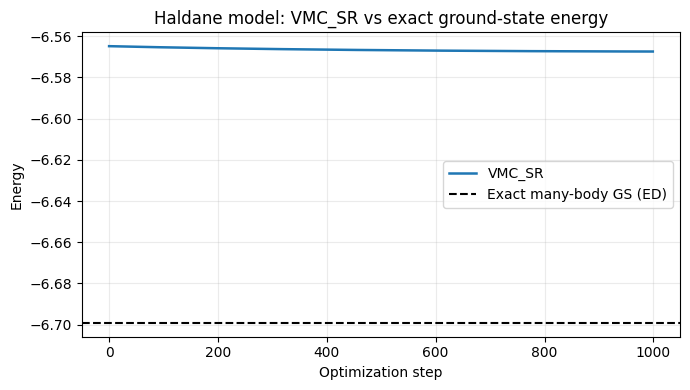

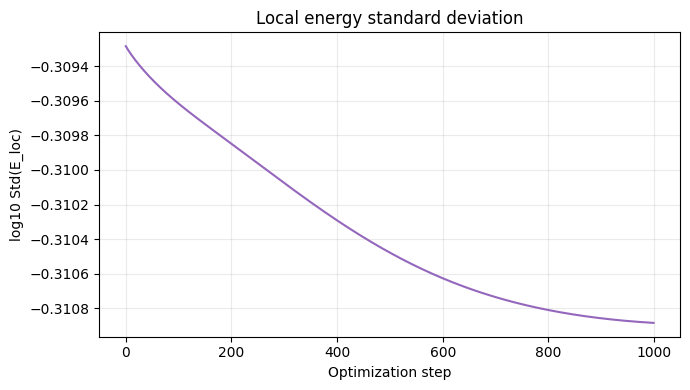

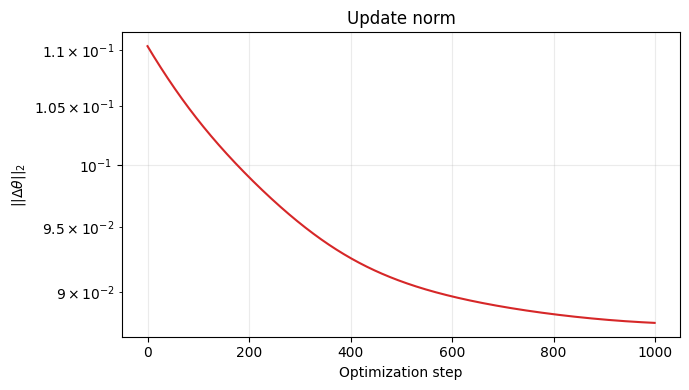

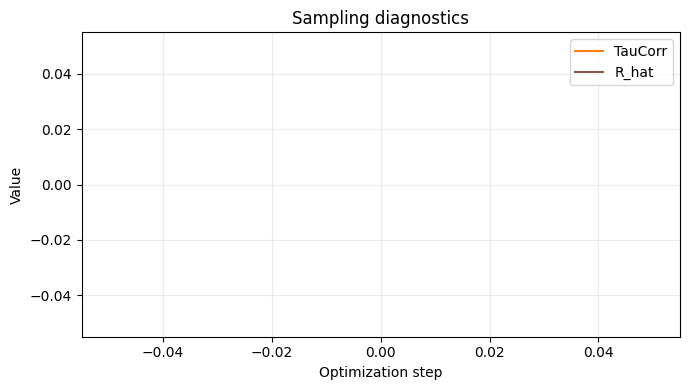

Exact ground-state reference [ED (interacting)] = -6.6991867520
Final VMC_SR energy (real part) = -6.5674133917
Final error (VMC - reference) = 0.1317733603
Final update norm ||dtheta||_2 = 8.773127e-02
Final local-energy std dev = 0.4887827644


In [21]:
#plot optimization data

import math

energy_history = log.data["Energy"]
iters = np.asarray(energy_history.iters)
energy_mean = np.asarray(energy_history["Mean"])
energy_sigma = np.asarray(energy_history["Sigma"])
energy_variance = np.asarray(energy_history["Variance"])

energy_std_local = np.sqrt(np.maximum(np.real(energy_variance), 0.0))
energy_tau = np.asarray(energy_history["TauCorr"])
energy_rhat = np.asarray(energy_history["R_hat"])

# acceptance_history = log.data.get("acceptance", None)
# acceptance_iters = np.asarray(acceptance_history.iters)
# acceptance_values = np.asarray(acceptance_history)

update_norm_history = log.data.get("UpdateNormL2", None)
update_norm_iters = np.asarray(update_norm_history.iters) if update_norm_history is not None else None
update_norm_values = np.asarray(update_norm_history) if update_norm_history is not None else None

# Exact reference: skip if C(n_sites, n_fermions) exceeds cutoff.
reference_dim_cutoff = 100_000
hilbert_dim_comb = math.comb(int(hi.n_orbitals), int(hi.n_fermions))
compute_reference = hilbert_dim_comb <= reference_dim_cutoff

if compute_reference:
    e_ref, e_ref_plot_label, e_ref_method = exact_reference_ground_state_energy(
        hamiltonian=ham,
        Lx=Lx,
        Ly=Ly,
        n_fermions=int(hi.n_fermions),
        t1=t1,
        t2=t2,
        phi=phi,
        m=m,
        V1=V1,
    )
else:
    e_ref = None
    e_ref_plot_label = None
    e_ref_method = (
        f"skipped (C(n_sites,n_fermions)={hilbert_dim_comb} > {reference_dim_cutoff})"
    )

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(iters, energy_mean.real, lw=1.8, color="tab:blue", label="VMC_SR")
ax.fill_between(
    iters,
    energy_mean.real - energy_sigma,
    energy_mean.real + energy_sigma,
    color="tab:blue",
    alpha=0.2,
    linewidth=0,
)
if e_ref is not None:
    ax.axhline(e_ref, color="black", ls="--", lw=1.5, label=e_ref_plot_label)
    ax.set_title("Haldane model: VMC_SR vs exact ground-state energy")
else:
    ax.set_title("Haldane model: VMC_SR energy")
ax.set_xlabel("Optimization step")
ax.set_ylabel("Energy")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(iters, np.log10(energy_std_local), color="tab:purple", lw=1.5)
ax.set_xlabel("Optimization step")
ax.set_ylabel("log10 Std(E_loc)")
ax.set_title("Local energy standard deviation")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# fig, ax = plt.subplots(figsize=(7, 4))
# if acceptance_values is not None:
#     ax.plot(acceptance_iters, acceptance_values, color="tab:green", lw=1.5)
#     ax.set_ylim(0.0, 1.0)
# else:
#     ax.text(0.5, 0.5, "Acceptance not available", ha="center", va="center", transform=ax.transAxes)
# ax.set_xlabel("Optimization step")
# ax.set_ylabel("Acceptance")
# ax.set_title("MC acceptance")
# ax.grid(alpha=0.25)
# plt.tight_layout()
# plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
if update_norm_values is not None:
    ax.plot(update_norm_iters, update_norm_values, color="tab:red", lw=1.5)
    ax.set_yscale("log")
else:
    ax.text(0.5, 0.5, "Update norm not available", ha="center", va="center", transform=ax.transAxes)
ax.set_xlabel("Optimization step")
ax.set_ylabel(r"||$\Delta\theta$||$_2$")
ax.set_title("Update norm")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
if energy_tau is not None:
    ax.plot(iters, energy_tau, color="tab:orange", lw=1.5, label="TauCorr")
    if energy_rhat is not None:
        ax.plot(iters, energy_rhat, color="tab:brown", lw=1.5, label="R_hat")
        ax.legend()
    ax.set_title("Sampling diagnostics")
else:
    ax.text(0.5, 0.5, "No extra diagnostics available", ha="center", va="center", transform=ax.transAxes)
    ax.set_title("Sampling diagnostics")
ax.set_xlabel("Optimization step")
ax.set_ylabel("Value")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

if e_ref is not None:
    print(f"Exact ground-state reference [{e_ref_method}] = {e_ref:.10f}")
    print(f"Final VMC_SR energy (real part) = {energy_mean.real[-1]:.10f}")
    print(f"Final error (VMC - reference) = {energy_mean.real[-1] - e_ref:.10f}")
else:
    print(f"Exact ground-state reference [{e_ref_method}]")
    print(f"Final VMC_SR energy (real part) = {energy_mean.real[-1]:.10f}")
# if acceptance_values is not None:
#     print(f"Final MC acceptance = {float(acceptance_values[-1]):.6f}")
if update_norm_values is not None:
    print(f"Final update norm ||dtheta||_2 = {float(update_norm_values[-1]):.6e}")
print(f"Final local-energy std dev = {float(energy_std_local[-1]):.10f}")


In [ ]:
Exact ground-state reference [ED (interacting)] = -5.1581151039
Final VMC_SR energy (real part) = -5.0459358859
Final error (VMC - reference) = 0.1121792180
Final update norm ||dtheta||_2 = 1.719536e-03
Final local-energy std dev = 0.3115943501

In [ ]:
Exact ground-state reference [ED (interacting)] = -5.1581151039
Final VMC_SR energy (real part) = -5.0636353328
Final error (VMC - reference) = 0.0944797711
Final update norm ||dtheta||_2 = 2.642128e-02
Final local-energy std dev = 0.1761074704

In [ ]:
Exact ground-state reference [ED (interacting)] = -5.1581151039
Final VMC_SR energy (real part) = -5.0812586455
Final error (VMC - reference) = 0.0768564584
Final update norm ||dtheta||_2 = 2.469766e-02
Final local-energy std dev = 0.1323244007

In [23]:
# Post-training observables input data from the optimized state.
# Works for both MCState (fresh samples) and FullSumState (exact weighted basis sum).
import netket as nk

if isinstance(vstate, nk.vqs.FullSumState):
    states_obs = np.asarray(hi.all_states(), dtype=float).reshape(-1, hi.size)
    psi_obs = np.asarray(vstate.to_array())
    prob_obs = np.abs(psi_obs) ** 2
    prob_sum = float(prob_obs.sum())
    if prob_sum <= 0.0:
        raise RuntimeError("Wavefunction probability norm is non-positive.")

    sample_weights_obs = (prob_obs / prob_sum).astype(float)
    samples_obs = states_obs
    n_samples_obs = int(samples_obs.shape[0])
    n_sites_obs = int(samples_obs.shape[1])
    positions_obs = np.asarray(graph.positions, dtype=float)
    obs_sampling_run = int(globals().get("obs_sampling_run", 0)) + 1
    obs_source = "fullsum_exact"

    n_eff = 1.0 / float(np.sum(sample_weights_obs**2))
    print(
        f"Post-training observables run {obs_sampling_run}: FullSum exact evaluation over "
        f"{n_samples_obs} basis states (effective sample size={n_eff:.1f})."
    )

else:
    obs_n_samples = max(4096 * 10, getattr(vstate, "n_samples", 4096 * 10))
    obs_n_discard_per_chain = max(64, getattr(vstate, "n_discard_per_chain", 64))

    # vstate.reset()
    samples_obs = np.asarray(
        vstate.sample(
            n_samples=obs_n_samples,
            n_discard_per_chain=obs_n_discard_per_chain,
        )
    ).reshape(-1, hi.size).astype(float)

    sample_weights_obs = None
    n_samples_obs = int(samples_obs.shape[0])
    n_sites_obs = int(samples_obs.shape[1])
    positions_obs = np.asarray(graph.positions, dtype=float)
    obs_sampling_run = int(globals().get("obs_sampling_run", 0)) + 1
    obs_source = "mc_samples"

    print(
        f"Post-training observables run {obs_sampling_run}: {n_samples_obs} MC samples "
        f"(single batch of {obs_n_samples}), discard_per_chain={obs_n_discard_per_chain}."
    )



Post-training observables run 4: FullSum exact evaluation over 10626 basis states (effective sample size=342.7).


Using post-training observables input from run 4: source=fullsum_exact, n_configs=10626


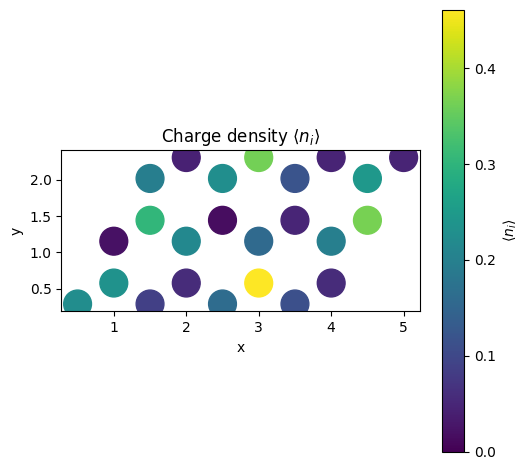

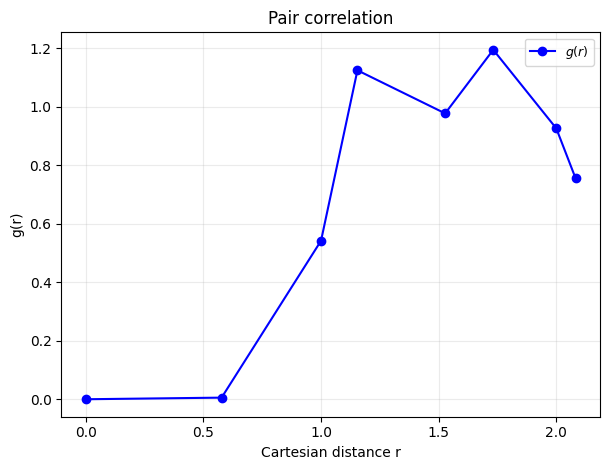

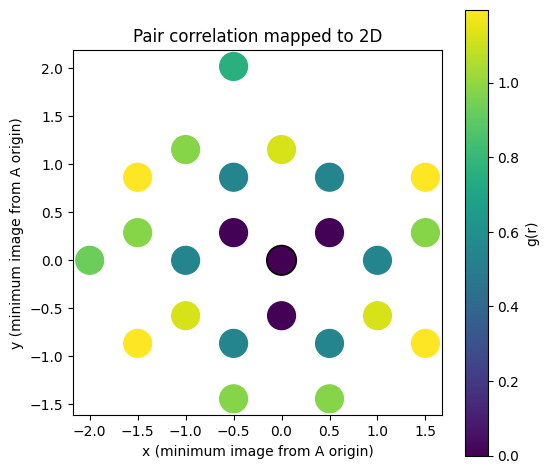

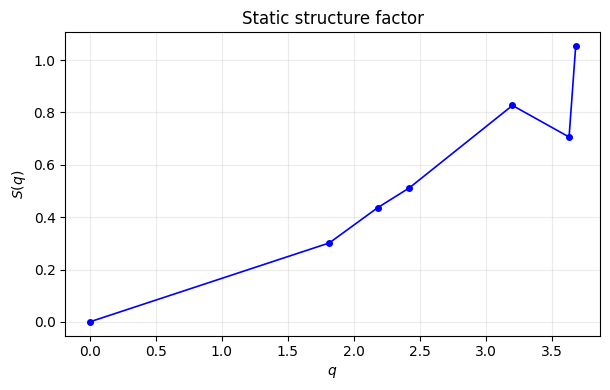

In [24]:
# Post-training observables from optimized wavefunction.
# Supports both MC samples and exact FullSum weighted basis-state evaluation.
import numpy as np
import matplotlib.pyplot as plt

from aidan_custom.observables import (
    map_radial_g_to_minimum_image_2d,
    minimum_image_translations,
    pair_correlation_cartesian,
    radial_average_structure_factor,
    static_structure_factor,
)

if "samples_obs" not in globals():
    raise RuntimeError("Run the post-training observables-input cell before this plotting cell.")

samples = np.asarray(samples_obs, dtype=float)
weights = globals().get("sample_weights_obs", None)
if weights is not None:
    weights = np.asarray(weights, dtype=float).reshape(-1)
    if weights.shape[0] != samples.shape[0]:
        raise ValueError("sample_weights_obs length does not match samples_obs length.")
    wsum = float(weights.sum())
    if wsum <= 0.0:
        raise ValueError("sample_weights_obs must have positive total weight.")
    weights = weights / wsum

n_samples = int(n_samples_obs)
n_sites = int(n_sites_obs)
positions = positions_obs
basis_vectors = np.asarray(graph.basis_vectors, dtype=float)

print(
    f"Using post-training observables input from run {obs_sampling_run}: "
    f"source={obs_source}, n_configs={n_samples}"
)

if weights is None:
    pc_data = pair_correlation_cartesian(
        samples=samples,
        positions=positions,
        basis_vectors=basis_vectors,
        pbc=np.asarray(graph.pbc, dtype=bool),
        Lx=Lx,
        Ly=Ly,
        n_fermions=n_fermions,
    )

    charge_density = pc_data["charge_density"]
    corr_matrix = pc_data["corr_matrix"]
    dist_matrix = pc_data["dist_matrix"]
    translations = pc_data["translations"]
    r_values_plot = pc_data["r_values_plot"]
    g_r_plot = pc_data["g_r_plot"]

    q_list, s_q = static_structure_factor(
        samples=samples,
        positions=positions,
        basis_vectors=basis_vectors,
        Lx=Lx,
        Ly=Ly,
        n_fermions=n_fermions,
    )

else:
    charge_density = np.einsum("s,si->i", weights, samples, optimize=True)
    corr_matrix = np.einsum("s,si,sj->ij", weights, samples, samples, optimize=True)

    disp = positions[:, np.newaxis, :] - positions[np.newaxis, :, :]
    translations = minimum_image_translations(
        basis_vectors,
        Lx=Lx,
        Ly=Ly,
        pbc=np.asarray(graph.pbc, dtype=bool),
    )
    dist_matrix = np.full((n_sites, n_sites), np.inf, dtype=float)
    for t in translations:
        dist_matrix = np.minimum(dist_matrix, np.linalg.norm(disp + t, axis=-1))

    offdiag = ~np.eye(n_sites, dtype=bool)
    dist_shell = np.round(dist_matrix, 12)
    r_values = np.unique(dist_shell[offdiag])

    g_r = np.empty(r_values.size, dtype=float)
    norm_density = (n_fermions / n_sites) ** 2
    for i, r in enumerate(r_values):
        mask = (dist_shell == r) & offdiag
        g_r[i] = corr_matrix[mask].mean().real / norm_density

    if r_values.size == 0 or not np.isclose(r_values[0], 0.0):
        r_values_plot = np.concatenate(([0.0], r_values))
        g_r_plot = np.concatenate(([0.0], g_r))
    else:
        r_values_plot = r_values.copy()
        g_r_plot = g_r.copy()
        g_r_plot[0] = 0.0

    q_list, _ = static_structure_factor(
        samples=samples,
        positions=positions,
        basis_vectors=basis_vectors,
        Lx=Lx,
        Ly=Ly,
        n_fermions=n_fermions,
    )
    phases = np.exp(-1j * (positions @ q_list.T))
    rho_q = samples @ phases
    s_q = np.einsum("s,sq->q", weights, np.abs(rho_q) ** 2, optimize=True) / n_fermions


rel_min, g_site, origin_idx, r_site = map_radial_g_to_minimum_image_2d(
    positions=positions,
    basis_coords=np.asarray(graph.basis_coords),
    translations=translations,
    r_values_plot=r_values_plot,
    g_r_plot=g_r_plot,
)

q_shell_unique, s_q_abs, s_q_abs_err, q_abs, s_q_plot = radial_average_structure_factor(
    q_list,
    s_q,
    set_q0_to_zero=True,
)

fig_charge, ax_charge = plt.subplots(figsize=(5.4, 4.8))
sc0 = ax_charge.scatter(
    positions[:, 0],
    positions[:, 1],
    c=charge_density,
    s=400,
    cmap="viridis",
    marker="o",
    clim=(0, np.amax(charge_density)),
)
ax_charge.set_title(r"Charge density $\langle n_i \rangle$")
ax_charge.set_xlabel("x")
ax_charge.set_ylabel("y")
ax_charge.set_aspect("equal", "box")
fig_charge.colorbar(sc0, ax=ax_charge, label=r"$\langle n_i \rangle$")
plt.tight_layout()
plt.show()

fig_pair, ax_pair = plt.subplots(figsize=(6.2, 4.8))
ax_pair.plot(r_values_plot, g_r_plot, "o-", label=r"$g(r)$", color="blue")
ax_pair.set_title("Pair correlation")
ax_pair.set_xlabel("Cartesian distance r")
ax_pair.set_ylabel("g(r)")
ax_pair.grid(alpha=0.25)
ax_pair.legend(fontsize=9)
plt.tight_layout()
plt.show()

fig_pair2d, ax_pair2d = plt.subplots(figsize=(5.6, 5.0))
sc_pair2d = ax_pair2d.scatter(
    rel_min[:, 0],
    rel_min[:, 1],
    c=g_site,
    s=400,
    cmap="viridis",
    marker="o",
)
ax_pair2d.scatter(
    [0.0],
    [0.0],
    s=450,
    facecolors="none",
    edgecolors="black",
    linewidths=1.2,
)
ax_pair2d.set_title("Pair correlation mapped to 2D")
ax_pair2d.set_xlabel("x (minimum image from A origin)")
ax_pair2d.set_ylabel("y (minimum image from A origin)")
ax_pair2d.set_aspect("equal", "box")
fig_pair2d.colorbar(sc_pair2d, ax=ax_pair2d, label="g(r)")
plt.tight_layout()
plt.show()

fig_abs, ax_abs = plt.subplots(figsize=(6.2, 4.0))
ax_abs.errorbar(
    q_shell_unique,
    s_q_abs,
    yerr=s_q_abs_err,
    fmt="o-",
    ms=4,
    lw=1.2,
    capsize=2,
    color="blue",
)
ax_abs.set_title(r"Static structure factor")
ax_abs.set_xlabel(r"$q$")
ax_abs.set_ylabel(r"$S(q)$")
ax_abs.grid(alpha=0.25)
plt.tight_layout()
plt.show()



Plotting Spatial-ViT class-wise maps for 2 layers x 2 heads. Uniform row class-counts: False


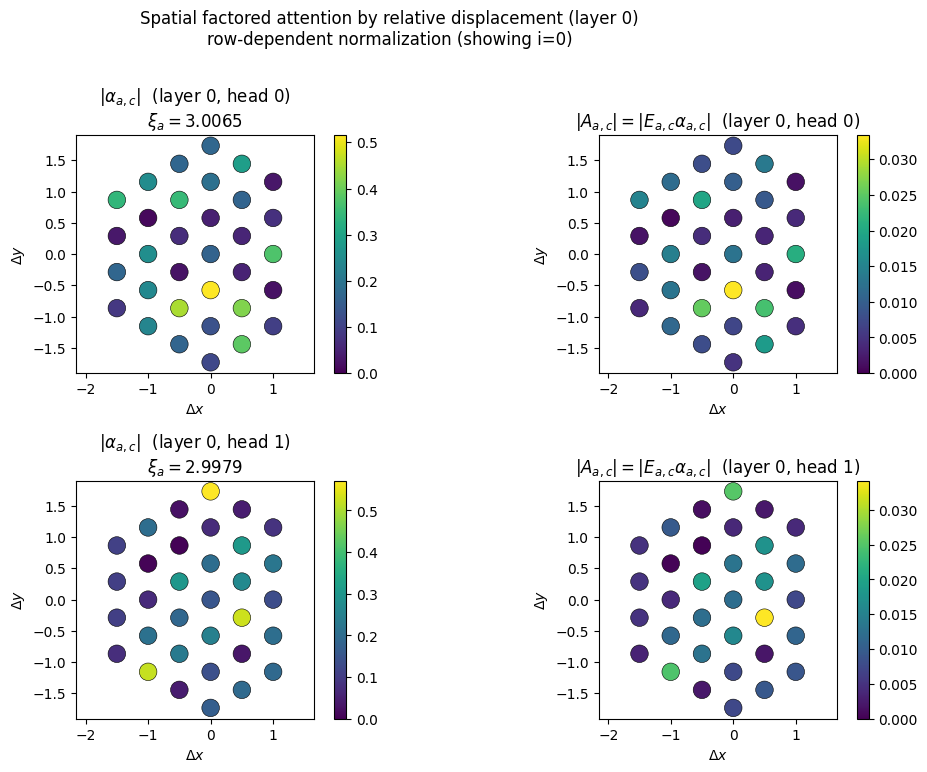

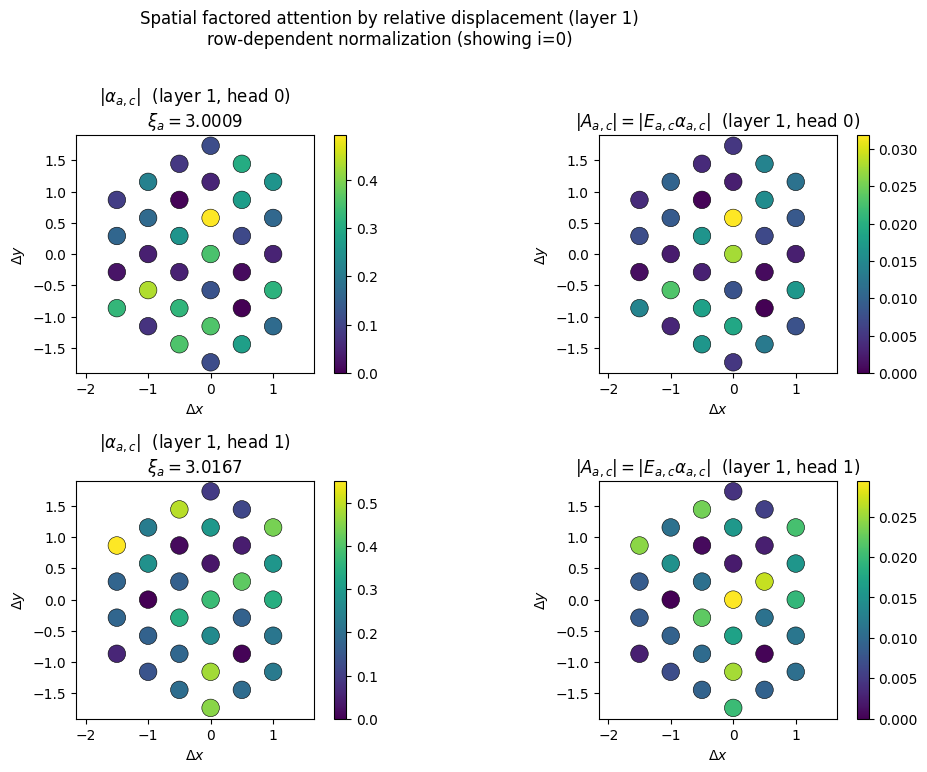

In [24]:
# Visualize Spatial-ViT attention as functions of relative lattice displacement (scatter by pair class)
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp

if "model" not in globals() or "vstate" not in globals():
    raise RuntimeError("Run the model construction/optimization cell before this visualization cell.")

if not isinstance(model, LogSlaterSpatialViT):
    raise RuntimeError("This cell currently expects model = LogSlaterSpatialViT.")


def _spatial_attention_class_maps_from_params(
    attn_params,
    pair_distances,
    class_counts_by_row,
    class_counts_uniform,
    xi_epsilon,
    is_uniform_row_class_count,
    reference_row=0,
):
    # Written with Codex 02-19-26.
    alpha = np.asarray(attn_params["alpha"], dtype=np.float64)
    raw_xi = np.asarray(attn_params["raw_xi"], dtype=np.float64)

    xi = np.asarray(jax.nn.softplus(jnp.asarray(raw_xi)) + xi_epsilon, dtype=np.float64)
    envelope_unnorm = np.exp(-pair_distances[None, :] / xi[:, None])

    if is_uniform_row_class_count:
        norm_denom = np.sum(
            envelope_unnorm * class_counts_uniform[None, :],
            axis=-1,
            keepdims=True,
        )
        envelope_norm = envelope_unnorm / norm_denom
        normalization_note = "uniform normalization (independent of i)"
    else:
        # Exact implementation has row-dependent normalization in this branch.
        # For class-wise scatter plotting we show one representative target row i=reference_row.
        norm_denom_hi = np.einsum(
            "hc,ic->hi",
            envelope_unnorm,
            class_counts_by_row,
            optimize=True,
        )
        envelope_norm = envelope_unnorm / norm_denom_hi[:, [reference_row]]
        normalization_note = f"row-dependent normalization (showing i={reference_row})"

    # A_{a,c} = E_{a,c} * alpha_{a,c}
    attention_amplitude = envelope_norm * alpha
    return xi, alpha, attention_amplitude, normalization_note


params = vstate.parameters
vit_params = params["vit"] if "vit" in params else params
encoder_params = vit_params["encoder"]

pair_classes = np.asarray(model.pair_classes, dtype=np.int32)
pair_distances = np.asarray(model.pair_distances, dtype=np.float64).reshape(-1)

if "pair_vectors" in globals():
    pair_vectors_arr = np.asarray(pair_vectors, dtype=np.float64)
else:
    _, _, pair_vectors_arr = make_translation_equivariant_pair_data_from_graph(graph)
    pair_vectors_arr = np.asarray(pair_vectors_arr, dtype=np.float64)

if pair_vectors_arr.shape[0] != pair_distances.size:
    raise ValueError(
        f"pair_vectors count ({pair_vectors_arr.shape[0]}) does not match n_pair_classes ({pair_distances.size})."
    )

n_pair_classes = pair_distances.size
one_hot_classes = jax.nn.one_hot(
    jnp.asarray(pair_classes),
    n_pair_classes,
    dtype=jnp.float64,
)
class_counts_by_row = np.asarray(jnp.sum(one_hot_classes, axis=1), dtype=np.float64)
class_counts_uniform = class_counts_by_row[0]
is_uniform_row_class_count = bool(
    np.all(class_counts_by_row == class_counts_uniform[None, :])
)

print(
    f"Plotting Spatial-ViT class-wise maps for {model.num_layers} layers x {model.n_heads} heads. "
    f"Uniform row class-counts: {is_uniform_row_class_count}"
)

x = pair_vectors_arr[:, 0]
y = pair_vectors_arr[:, 1]

for layer_idx in range(int(model.num_layers)):
    block_name = f"block_{layer_idx}"
    if block_name not in encoder_params:
        raise KeyError(f"Missing encoder params for {block_name}")

    attn_params = encoder_params[block_name]["attn"]
    xi, alpha_by_class, attention_amplitude, normalization_note = (
        _spatial_attention_class_maps_from_params(
            attn_params=attn_params,
            pair_distances=pair_distances,
            class_counts_by_row=class_counts_by_row,
            class_counts_uniform=class_counts_uniform,
            xi_epsilon=float(model.xi_epsilon),
            is_uniform_row_class_count=is_uniform_row_class_count,
            reference_row=0,
        )
    )

    n_heads = int(model.n_heads)
    fig, axes = plt.subplots(n_heads, 2, figsize=(11, 3.8 * n_heads), squeeze=False)

    for head_idx in range(n_heads):
        ax_alpha = axes[head_idx, 0]
        ax_a = axes[head_idx, 1]

        alpha_vals = np.abs(alpha_by_class[head_idx])
        a_vals = np.abs(attention_amplitude[head_idx])

        s = 160.0

        vmax_alpha = float(np.max(alpha_vals))
        if vmax_alpha == 0.0:
            vmax_alpha = 1.0
        sc_alpha = ax_alpha.scatter(
            x,
            y,
            c=alpha_vals,
            s=s,
            cmap="viridis",
            vmin=0.0,
            vmax=vmax_alpha,
            edgecolors="k",
            linewidths=0.4,
        )
        fig.colorbar(sc_alpha, ax=ax_alpha, fraction=0.046, pad=0.04)
        ax_alpha.set_title(
            rf"$|\alpha_{{a,c}}|$  (layer {layer_idx}, head {head_idx})" + "\n"
            + rf"$\xi_a={xi[head_idx]:.4f}$"
        )
        ax_alpha.set_xlabel(r"$\Delta x$")
        ax_alpha.set_ylabel(r"$\Delta y$")
        ax_alpha.set_aspect("equal")
        ax_alpha.set_box_aspect(1)

        vmax_a = float(np.max(a_vals))
        if vmax_a == 0.0:
            vmax_a = 1.0
        sc_a = ax_a.scatter(
            x,
            y,
            c=a_vals,
            s=s,
            cmap="viridis",
            vmin=0.0,
            vmax=vmax_a,
            edgecolors="k",
            linewidths=0.4,
        )
        fig.colorbar(sc_a, ax=ax_a, fraction=0.046, pad=0.04)
        ax_a.set_title(
            rf"$|A_{{a,c}}| = |E_{{a,c}}\alpha_{{a,c}}|$  (layer {layer_idx}, head {head_idx})"
        )
        ax_a.set_xlabel(r"$\Delta x$")
        ax_a.set_ylabel(r"$\Delta y$")
        ax_a.set_aspect("equal")
        ax_a.set_box_aspect(1)

    fig.suptitle(
        f"Spatial factored attention by relative displacement (layer {layer_idx})\n{normalization_note}",
        y=1.01,
        fontsize=12,
    )
    plt.tight_layout()
    plt.show()




In [ ]:
# Export the current notebook state to a script-style job folder in results/.
from pathlib import Path
from datetime import datetime
import json
import math
import shutil

import flax.serialization
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import netket as nk
import numpy as np

from aidan_custom.models import LogSlaterSpatialViT, make_translation_equivariant_pair_data_from_graph
from aidan_custom.observables import (
    map_radial_g_to_minimum_image_2d,
    minimum_image_translations,
    pair_correlation_cartesian,
    radial_average_structure_factor,
    static_structure_factor,
)
from aidan_custom.optimization import exact_reference_ground_state_energy

if "vstate" not in globals():
    raise RuntimeError("vstate is missing. Run the optimization cell first.")
if "hi" not in globals() or "graph" not in globals():
    raise RuntimeError("hi/graph are missing. Run the setup cells first.")
if "log" not in globals():
    raise RuntimeError("log is missing. Run the optimization cell first.")

cwd = Path.cwd()
if (cwd / "results").exists():
    repo_root = cwd
elif (cwd.parent / "results").exists():
    repo_root = cwd.parent
else:
    raise RuntimeError("Could not locate repository root containing results/.")

notebook_candidates = [
    repo_root / "notebooks" / "haldane_model.ipynb",
    cwd / "haldane_model.ipynb",
]
notebook_path = None
for candidate in notebook_candidates:
    if candidate.exists():
        notebook_path = candidate
        break
if notebook_path is None:
    raise RuntimeError("Could not find haldane_model.ipynb to copy into results.")

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
job_dir = repo_root / "results" / f"job_haldane_notebook_snapshot_{timestamp}"
job_dir.mkdir(parents=True, exist_ok=False)

plots_optimization_dir = job_dir / "plots_optimization"
plots_observables_dir = job_dir / "plots_observables"
plots_attention_dir = job_dir / "plots_attention"
raw_data_dir = job_dir / "raw_data"
scripts_dir = job_dir / "scripts"
for path in [plots_optimization_dir, plots_observables_dir, plots_attention_dir, raw_data_dir, scripts_dir]:
    path.mkdir(parents=True, exist_ok=True)

shutil.copy2(notebook_path, job_dir / notebook_path.name)

# Save vstate variables and parameter tree.
(job_dir / "vstate_variables.mpack").write_bytes(flax.serialization.to_bytes(vstate.variables))
param_leaves, param_treedef = jax.tree_util.tree_flatten(vstate.parameters)
np.savez(job_dir / "vstate_parameters_leaves.npz", *[np.asarray(x) for x in param_leaves])
(job_dir / "vstate_parameters_treedef.txt").write_text(repr(param_treedef) + "\n")

# Save RuntimeLog in NetKet format.
log.serialize(job_dir / "runtime_log")

energy_history = log.data["Energy"]
iters = np.asarray(energy_history.iters)
energy_mean = np.asarray(energy_history["Mean"])
energy_sigma = np.asarray(energy_history["Sigma"])
energy_variance = np.asarray(energy_history["Variance"])
energy_std_local = np.sqrt(np.maximum(np.real(energy_variance), 0.0))

try:
    energy_tau = np.asarray(energy_history["TauCorr"])
except Exception:
    energy_tau = np.asarray([])

try:
    energy_rhat = np.asarray(energy_history["R_hat"])
except Exception:
    energy_rhat = np.asarray([])

update_norm_history = log.data.get("UpdateNormL2", None)
if update_norm_history is not None:
    update_norm_iters = np.asarray(update_norm_history.iters)
    update_norm_values = np.asarray(update_norm_history)
else:
    update_norm_iters = np.asarray([], dtype=np.int64)
    update_norm_values = np.asarray([], dtype=np.float64)

np.savez(
    raw_data_dir / "optimization_history.npz",
    iters=iters,
    energy_mean=energy_mean,
    energy_sigma=energy_sigma,
    energy_variance=energy_variance,
    energy_std_local=energy_std_local,
    energy_tau=energy_tau,
    energy_rhat=energy_rhat,
    update_norm_iters=update_norm_iters,
    update_norm_values=update_norm_values,
)

reference_dim_cutoff = 100_000
hilbert_dim_comb = math.comb(int(hi.n_orbitals), int(hi.n_fermions))
has_reference_inputs = all(
    name in globals() for name in ["ham", "Lx", "Ly", "t1", "t2", "phi", "m", "V1"]
)
if hilbert_dim_comb <= reference_dim_cutoff and has_reference_inputs:
    e_ref, e_ref_plot_label, e_ref_method = exact_reference_ground_state_energy(
        hamiltonian=ham,
        Lx=Lx,
        Ly=Ly,
        n_fermions=int(hi.n_fermions),
        t1=t1,
        t2=t2,
        phi=phi,
        m=m,
        V1=V1,
    )
else:
    e_ref = None
    e_ref_plot_label = None
    if not has_reference_inputs:
        e_ref_method = "skipped (missing globals for exact reference)"
    else:
        e_ref_method = (
            f"skipped (C(n_sites,n_fermions)={hilbert_dim_comb} > {reference_dim_cutoff})"
        )

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(iters, np.real(energy_mean), lw=1.8, color="tab:blue", label="VMC_SR")
ax.fill_between(
    iters,
    np.real(energy_mean) - energy_sigma,
    np.real(energy_mean) + energy_sigma,
    color="tab:blue",
    alpha=0.2,
    linewidth=0,
)
if e_ref is not None:
    ax.axhline(e_ref, color="black", ls="--", lw=1.5, label=e_ref_plot_label)
    ax.set_title("Haldane model: VMC_SR vs exact ground-state energy")
else:
    ax.set_title("Haldane model: VMC_SR energy")
ax.set_xlabel("Optimization step")
ax.set_ylabel("Energy")
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(plots_optimization_dir / "energy_vs_step.png", dpi=180)
plt.close(fig)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(iters, np.log10(np.maximum(energy_std_local, 1e-30)), color="tab:purple", lw=1.5)
ax.set_xlabel("Optimization step")
ax.set_ylabel("log10 Std(E_loc)")
ax.set_title("Local energy standard deviation")
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(plots_optimization_dir / "local_energy_std_log10.png", dpi=180)
plt.close(fig)

fig, ax = plt.subplots(figsize=(7, 4))
if update_norm_values.size > 0:
    ax.plot(update_norm_iters, update_norm_values, color="tab:red", lw=1.5)
    ax.set_yscale("log")
else:
    ax.text(0.5, 0.5, "Update norm not available", ha="center", va="center", transform=ax.transAxes)
ax.set_xlabel("Optimization step")
ax.set_ylabel(r"||$\Delta\theta$||$_2$")
ax.set_title("Update norm")
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(plots_optimization_dir / "update_norm.png", dpi=180)
plt.close(fig)

fig, ax = plt.subplots(figsize=(7, 4))
if energy_tau.size > 0:
    ax.plot(iters, energy_tau, color="tab:orange", lw=1.5, label="TauCorr")
    if energy_rhat.size > 0:
        ax.plot(iters, energy_rhat, color="tab:brown", lw=1.5, label="R_hat")
    ax.legend()
    ax.set_title("Sampling diagnostics")
else:
    ax.text(0.5, 0.5, "No extra diagnostics available", ha="center", va="center", transform=ax.transAxes)
    ax.set_title("Sampling diagnostics")
ax.set_xlabel("Optimization step")
ax.set_ylabel("Value")
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(plots_optimization_dir / "sampling_diagnostics.png", dpi=180)
plt.close(fig)

# Observables input generation.
if isinstance(vstate, nk.vqs.FullSumState):
    states_obs = np.asarray(hi.all_states(), dtype=float).reshape(-1, hi.size)
    psi_obs = np.asarray(vstate.to_array())
    prob_obs = np.abs(psi_obs) ** 2
    prob_sum = float(prob_obs.sum())
    if prob_sum <= 0.0:
        raise RuntimeError("Wavefunction probability norm is non-positive.")

    sample_weights_obs = (prob_obs / prob_sum).astype(float)
    samples_obs = states_obs
    obs_source = "fullsum_exact"
else:
    obs_n_samples = max(4096 * 10, getattr(vstate, "n_samples", 4096 * 10))
    obs_n_discard_per_chain = max(64, getattr(vstate, "n_discard_per_chain", 64))
    samples_obs = np.asarray(
        vstate.sample(
            n_samples=obs_n_samples,
            n_discard_per_chain=obs_n_discard_per_chain,
        )
    ).reshape(-1, hi.size).astype(float)
    sample_weights_obs = None
    obs_source = "mc_samples"

positions_obs = np.asarray(graph.positions, dtype=float)
np.savez(
    raw_data_dir / "observables_samples.npz",
    samples_obs=samples_obs,
    sample_weights_obs=np.asarray([]) if sample_weights_obs is None else sample_weights_obs,
    positions_obs=positions_obs,
)

samples = np.asarray(samples_obs, dtype=float)
weights = sample_weights_obs
if weights is not None:
    weights = np.asarray(weights, dtype=float).reshape(-1)
    if weights.shape[0] != samples.shape[0]:
        raise ValueError("sample_weights_obs length does not match samples_obs length.")
    wsum = float(weights.sum())
    if wsum <= 0.0:
        raise ValueError("sample_weights_obs must have positive total weight.")
    weights = weights / wsum

n_samples = int(samples.shape[0])
n_sites = int(samples.shape[1])
positions = positions_obs
basis_vectors = np.asarray(graph.basis_vectors, dtype=float)

if weights is None:
    pc_data = pair_correlation_cartesian(
        samples=samples,
        positions=positions,
        basis_vectors=basis_vectors,
        pbc=np.asarray(graph.pbc, dtype=bool),
        Lx=Lx,
        Ly=Ly,
        n_fermions=n_fermions,
    )

    charge_density = pc_data["charge_density"]
    corr_matrix = pc_data["corr_matrix"]
    dist_matrix = pc_data["dist_matrix"]
    translations = pc_data["translations"]
    r_values_plot = pc_data["r_values_plot"]
    g_r_plot = pc_data["g_r_plot"]

    q_list, s_q = static_structure_factor(
        samples=samples,
        positions=positions,
        basis_vectors=basis_vectors,
        Lx=Lx,
        Ly=Ly,
        n_fermions=n_fermions,
    )
else:
    charge_density = np.einsum("s,si->i", weights, samples, optimize=True)
    corr_matrix = np.einsum("s,si,sj->ij", weights, samples, samples, optimize=True)

    disp = positions[:, np.newaxis, :] - positions[np.newaxis, :, :]
    translations = minimum_image_translations(
        basis_vectors,
        Lx=Lx,
        Ly=Ly,
        pbc=np.asarray(graph.pbc, dtype=bool),
    )
    dist_matrix = np.full((n_sites, n_sites), np.inf, dtype=float)
    for t in translations:
        dist_matrix = np.minimum(dist_matrix, np.linalg.norm(disp + t, axis=-1))

    offdiag = ~np.eye(n_sites, dtype=bool)
    dist_shell = np.round(dist_matrix, 12)
    r_values = np.unique(dist_shell[offdiag])

    g_r = np.empty(r_values.size, dtype=float)
    norm_density = (n_fermions / n_sites) ** 2
    for i, r in enumerate(r_values):
        mask = (dist_shell == r) & offdiag
        g_r[i] = corr_matrix[mask].mean().real / norm_density

    if r_values.size == 0 or not np.isclose(r_values[0], 0.0):
        r_values_plot = np.concatenate(([0.0], r_values))
        g_r_plot = np.concatenate(([0.0], g_r))
    else:
        r_values_plot = r_values.copy()
        g_r_plot = g_r.copy()
        g_r_plot[0] = 0.0

    q_list, _ = static_structure_factor(
        samples=samples,
        positions=positions,
        basis_vectors=basis_vectors,
        Lx=Lx,
        Ly=Ly,
        n_fermions=n_fermions,
    )
    phases = np.exp(-1j * (positions @ q_list.T))
    rho_q = samples @ phases
    s_q = np.einsum("s,sq->q", weights, np.abs(rho_q) ** 2, optimize=True) / n_fermions

rel_min, g_site, origin_idx, r_site = map_radial_g_to_minimum_image_2d(
    positions=positions,
    basis_coords=np.asarray(graph.basis_coords),
    translations=translations,
    r_values_plot=r_values_plot,
    g_r_plot=g_r_plot,
)

q_shell_unique, s_q_abs, s_q_abs_err, q_abs, s_q_plot = radial_average_structure_factor(
    q_list,
    s_q,
    set_q0_to_zero=True,
)

np.savez(
    raw_data_dir / "observables_derived.npz",
    charge_density=charge_density,
    corr_matrix=corr_matrix,
    dist_matrix=dist_matrix,
    translations=translations,
    r_values_plot=r_values_plot,
    g_r_plot=g_r_plot,
    q_list=q_list,
    s_q=s_q,
    rel_min=rel_min,
    g_site=g_site,
    origin_idx=np.asarray(origin_idx),
    r_site=r_site,
    q_shell_unique=q_shell_unique,
    s_q_abs=s_q_abs,
    s_q_abs_err=s_q_abs_err,
    q_abs=q_abs,
    s_q_plot=s_q_plot,
)

fig_charge, ax_charge = plt.subplots(figsize=(5.4, 4.8))
sc0 = ax_charge.scatter(
    positions[:, 0],
    positions[:, 1],
    c=charge_density,
    s=400,
    cmap="viridis",
    marker="o",
    clim=(0, float(np.amax(charge_density)) if charge_density.size else 1.0),
)
ax_charge.set_title(r"Charge density $\langle n_i \rangle$")
ax_charge.set_xlabel("x")
ax_charge.set_ylabel("y")
ax_charge.set_aspect("equal", "box")
fig_charge.colorbar(sc0, ax=ax_charge, label=r"$\langle n_i \rangle$")
fig_charge.tight_layout()
fig_charge.savefig(plots_observables_dir / "charge_density.png", dpi=180)
plt.close(fig_charge)

fig_pair, ax_pair = plt.subplots(figsize=(6.2, 4.8))
ax_pair.plot(r_values_plot, g_r_plot, "o-", label=r"$g(r)$", color="blue")
ax_pair.set_title("Pair correlation")
ax_pair.set_xlabel("Cartesian distance r")
ax_pair.set_ylabel("g(r)")
ax_pair.grid(alpha=0.25)
ax_pair.legend(fontsize=9)
fig_pair.tight_layout()
fig_pair.savefig(plots_observables_dir / "pair_correlation_radial.png", dpi=180)
plt.close(fig_pair)

fig_pair2d, ax_pair2d = plt.subplots(figsize=(5.6, 5.0))
sc_pair2d = ax_pair2d.scatter(
    rel_min[:, 0],
    rel_min[:, 1],
    c=g_site,
    s=400,
    cmap="viridis",
    marker="o",
)
ax_pair2d.scatter(
    [0.0],
    [0.0],
    s=450,
    facecolors="none",
    edgecolors="black",
    linewidths=1.2,
)
ax_pair2d.set_title("Pair correlation mapped to 2D")
ax_pair2d.set_xlabel("x (minimum image from A origin)")
ax_pair2d.set_ylabel("y (minimum image from A origin)")
ax_pair2d.set_aspect("equal", "box")
fig_pair2d.colorbar(sc_pair2d, ax=ax_pair2d, label="g(r)")
fig_pair2d.tight_layout()
fig_pair2d.savefig(plots_observables_dir / "pair_correlation_mapped_2d.png", dpi=180)
plt.close(fig_pair2d)

fig_abs, ax_abs = plt.subplots(figsize=(6.2, 4.0))
ax_abs.errorbar(
    q_shell_unique,
    s_q_abs,
    yerr=s_q_abs_err,
    fmt="o-",
    ms=4,
    lw=1.2,
    capsize=2,
    color="blue",
)
ax_abs.set_title(r"Static structure factor")
ax_abs.set_xlabel(r"$q$")
ax_abs.set_ylabel(r"$S(q)$")
ax_abs.grid(alpha=0.25)
fig_abs.tight_layout()
fig_abs.savefig(plots_observables_dir / "static_structure_factor.png", dpi=180)
plt.close(fig_abs)

attention_summary = {"enabled": False}
if "model" in globals() and isinstance(model, LogSlaterSpatialViT):
    params = vstate.parameters
    vit_params = params["vit"] if "vit" in params else params
    encoder_params = vit_params["encoder"]

    pair_classes = np.asarray(model.pair_classes, dtype=np.int32)
    pair_distances = np.asarray(model.pair_distances, dtype=np.float64).reshape(-1)

    if "pair_vectors" in globals():
        pair_vectors_arr = np.asarray(pair_vectors, dtype=np.float64)
    else:
        _, _, pair_vectors_arr = make_translation_equivariant_pair_data_from_graph(graph)
        pair_vectors_arr = np.asarray(pair_vectors_arr, dtype=np.float64)

    if pair_vectors_arr.shape[0] != pair_distances.size:
        raise ValueError(
            f"pair_vectors count ({pair_vectors_arr.shape[0]}) does not match n_pair_classes ({pair_distances.size})."
        )

    n_pair_classes = pair_distances.size
    one_hot_classes = jax.nn.one_hot(
        jnp.asarray(pair_classes),
        n_pair_classes,
        dtype=jnp.float64,
    )
    class_counts_by_row = np.asarray(jnp.sum(one_hot_classes, axis=1), dtype=np.float64)
    class_counts_uniform = class_counts_by_row[0]
    is_uniform_row_class_count = bool(
        np.all(class_counts_by_row == class_counts_uniform[None, :])
    )

    x = pair_vectors_arr[:, 0]
    y = pair_vectors_arr[:, 1]

    for layer_idx in range(int(model.num_layers)):
        block_name = f"block_{layer_idx}"
        attn_params = encoder_params[block_name]["attn"]

        alpha = np.asarray(attn_params["alpha"], dtype=np.float64)
        raw_xi = np.asarray(attn_params["raw_xi"], dtype=np.float64)

        xi = np.asarray(jax.nn.softplus(jnp.asarray(raw_xi)) + float(model.xi_epsilon), dtype=np.float64)
        envelope_unnorm = np.exp(-pair_distances[None, :] / xi[:, None])

        if is_uniform_row_class_count:
            norm_denom = np.sum(
                envelope_unnorm * class_counts_uniform[None, :],
                axis=-1,
                keepdims=True,
            )
            envelope_norm = envelope_unnorm / norm_denom
            normalization_note = "uniform normalization (independent of i)"
        else:
            norm_denom_hi = np.einsum(
                "hc,ic->hi",
                envelope_unnorm,
                class_counts_by_row,
                optimize=True,
            )
            envelope_norm = envelope_unnorm / norm_denom_hi[:, [0]]
            normalization_note = "row-dependent normalization (showing i=0)"

        attention_amplitude = envelope_norm * alpha

        np.savez(
            raw_data_dir / f"attention_layer_{layer_idx:02d}.npz",
            xi=xi,
            alpha=alpha,
            attention_amplitude=attention_amplitude,
            pair_distances=pair_distances,
            pair_vectors=pair_vectors_arr,
            class_counts_by_row=class_counts_by_row,
            class_counts_uniform=class_counts_uniform,
        )

        n_heads = int(model.n_heads)
        fig, axes = plt.subplots(n_heads, 2, figsize=(11, 3.8 * n_heads), squeeze=False)

        for head_idx in range(n_heads):
            ax_alpha = axes[head_idx, 0]
            ax_a = axes[head_idx, 1]

            alpha_vals = np.abs(alpha[head_idx])
            a_vals = np.abs(attention_amplitude[head_idx])

            vmax_alpha = float(np.max(alpha_vals))
            if vmax_alpha == 0.0:
                vmax_alpha = 1.0

            sc_alpha = ax_alpha.scatter(
                x,
                y,
                c=alpha_vals,
                s=160.0,
                cmap="viridis",
                vmin=0.0,
                vmax=vmax_alpha,
                edgecolors="k",
                linewidths=0.4,
            )
            fig.colorbar(sc_alpha, ax=ax_alpha, fraction=0.046, pad=0.04)
            ax_alpha.set_title(
                rf"$|\alpha_{{a,c}}|$  (layer {layer_idx}, head {head_idx})" + "\n"
                + rf"$\xi_a={xi[head_idx]:.4f}$"
            )
            ax_alpha.set_xlabel(r"$\Delta x$")
            ax_alpha.set_ylabel(r"$\Delta y$")
            ax_alpha.set_aspect("equal")
            ax_alpha.set_box_aspect(1)

            vmax_a = float(np.max(a_vals))
            if vmax_a == 0.0:
                vmax_a = 1.0

            sc_a = ax_a.scatter(
                x,
                y,
                c=a_vals,
                s=160.0,
                cmap="viridis",
                vmin=0.0,
                vmax=vmax_a,
                edgecolors="k",
                linewidths=0.4,
            )
            fig.colorbar(sc_a, ax=ax_a, fraction=0.046, pad=0.04)
            ax_a.set_title(
                rf"$|A_{{a,c}}| = |E_{{a,c}}\alpha_{{a,c}}|$  (layer {layer_idx}, head {head_idx})"
            )
            ax_a.set_xlabel(r"$\Delta x$")
            ax_a.set_ylabel(r"$\Delta y$")
            ax_a.set_aspect("equal")
            ax_a.set_box_aspect(1)

        fig.suptitle(
            f"Spatial factored attention by relative displacement (layer {layer_idx})\n{normalization_note}",
            y=1.01,
            fontsize=12,
        )
        fig.tight_layout()
        fig.savefig(plots_attention_dir / f"layer_{layer_idx:02d}_class_maps.png", dpi=180)
        plt.close(fig)

    attention_summary = {
        "enabled": True,
        "num_layers": int(model.num_layers),
        "n_heads": int(model.n_heads),
        "n_pair_classes": int(n_pair_classes),
        "uniform_row_class_counts": bool(is_uniform_row_class_count),
    }

# Save script copies used for training and plotting.
nb = json.loads(notebook_path.read_text())
script_cells = {
    "run_script.py": 8,
    "plot_optimization.py": 9,
    "observables_input.py": 13,
    "plot_observables.py": 14,
    "plot_attention.py": 15,
}
for filename, cell_idx in script_cells.items():
    if cell_idx < len(nb["cells"]) and nb["cells"][cell_idx].get("cell_type") == "code":
        source = "".join(nb["cells"][cell_idx].get("source", []))
        (scripts_dir / filename).write_text(source.rstrip() + "\n")

summary = {
    "timestamp": timestamp,
    "job_dir": str(job_dir),
    "model_type": globals().get("model_type", type(globals().get("model", None)).__name__),
    "sample_type": globals().get("sample_type", None),
    "Lx": int(globals().get("Lx", -1)),
    "Ly": int(globals().get("Ly", -1)),
    "n_fermions": int(globals().get("n_fermions", int(hi.n_fermions))),
    "V1": float(globals().get("V1", np.nan)),
    "t1": float(globals().get("t1", np.nan)),
    "t2": float(globals().get("t2", np.nan)),
    "phi": float(globals().get("phi", np.nan)),
    "m": float(globals().get("m", np.nan)),
    "n_iter": int(globals().get("n_iter", -1)),
    "n_samples": int(globals().get("n_samples", -1)) if "n_samples" in globals() else None,
    "final_energy_real": float(np.real(energy_mean[-1])) if energy_mean.size > 0 else None,
    "final_energy_sigma": float(energy_sigma[-1]) if energy_sigma.size > 0 else None,
    "final_update_norm": float(update_norm_values[-1]) if update_norm_values.size > 0 else None,
    "reference_method": e_ref_method,
    "reference_energy": None if e_ref is None else float(e_ref),
    "observables_source": obs_source,
    "observables_n_configs": int(n_samples),
    "attention": attention_summary,
    "artifacts": {
        "vstate_variables_mpack": "vstate_variables.mpack",
        "vstate_parameters_npz": "vstate_parameters_leaves.npz",
        "runtime_log": "runtime_log.json",
        "raw_data_dir": "raw_data",
        "plots_optimization_dir": "plots_optimization",
        "plots_observables_dir": "plots_observables",
        "plots_attention_dir": "plots_attention",
        "scripts_dir": "scripts",
        "notebook_copy": notebook_path.name,
    },
}
(job_dir / "summary.json").write_text(json.dumps(summary, indent=2, sort_keys=True) + "\n")

readme_lines = [
    "Haldane notebook snapshot exported from notebooks/haldane_model.ipynb.",
    "",
    "Contents:",
    "- vstate_variables.mpack: serialized NetKet/Flax state variables.",
    "- vstate_parameters_*.npz/txt: parameter leaves and treedef.",
    "- runtime_log.json: serialized optimization log.",
    "- raw_data/: optimization, observables, and attention arrays.",
    "- plots_optimization/: optimization diagnostics plots.",
    "- plots_observables/: post-training observables plots.",
    "- plots_attention/: Spatial-ViT attention plots (if applicable).",
    "- scripts/: code-cell copies used for training and plotting.",
    "- summary.json: key metadata and final metrics.",
]
(job_dir / "README.txt").write_text("\n".join(readme_lines) + "\n")

print(f"Saved notebook snapshot to: {job_dir}")
if energy_mean.size > 0:
    print(f"Final energy (real): {float(np.real(energy_mean[-1])):.12f}")
